# Chapter 5: Implementation and simulation of QEC codes: Framework setup and baseline models
## Simulating QEC codes and decoders with stim

### Simulation 1: minimal simulation of a basic repetition code with stim
The following code snippet shows the minimal source code to simulate a basic repetition code using stim and the pymatching library

In [1]:
%load_ext autoreload
%autoreload 2

```python
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt

#BEGIN S1_SNIPPET
def sample_repetition_code_mwpm(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    using the pymatching MWPM decoder.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        
        # Decode the syndromes using PyMatching
        matcher = pymatching.Matching.from_stim_circuit(circuit)
        predicted_observables = matcher.decode_batch(syndromes)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)

    return physical_error_rates, logical_error_rates
#END S1_SNIPPET

def plot_repetition_code_mwpm_performance(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates, logical_error_rates = sample_repetition_code_mwpm(distance, shots)
    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates, logical_error_rates, marker='o', label=f'Distance {distance}')
    
    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates, physical_error_rates, linestyle='--', color='gray', label='No QEC')
    plt.title('Repetition Code Performance (Code-Capacity, MWPM Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_mwpm_performance(distance=3, shots=10000)
```

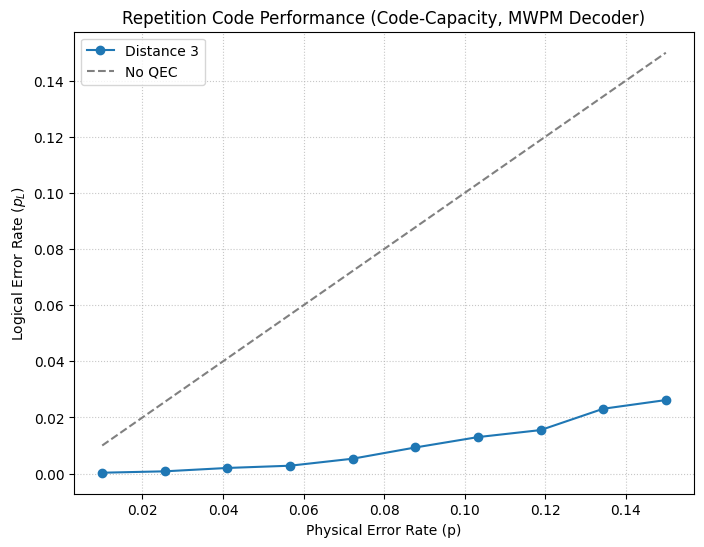

In [2]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s1_stim_rep_code.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's1_stim_rep_code.py'

plt.savefig('../../figures/chapter_5/stim_rep_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 2: minimal simulation of a Majority Vote decoder with stim
The following code snippet shows the minimal source code to simulate a basic repetition code using stim and a custom Majority Vote decoder

```python
import stim
import numpy as np
import matplotlib.pyplot as plt
from s2_majority_vote_decoder import decode_batch_majority_vote

def sample_repetition_code_mv(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        # Decode the syndromes using our decoder
        predicted_observables = decode_batch_majority_vote(syndromes, circuit, distance)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)
    return physical_error_rates, logical_error_rates

def plot_repetition_code_mv_performance(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates and plots a repetition code over a range of physical error rates,
    using the majority vote decoder.
    """
    physical_error_rates, logical_error_rates = sample_repetition_code_mv(distance, shots)

    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates, logical_error_rates, marker='o', label=f'Distance {distance}')
    
    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates, physical_error_rates, linestyle='--', color='gray', label='No QEC')
    
    plt.title('Repetition Code Performance (Code-Capacity, Majority Vote Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_mv_performance(distance=3, shots=10000)
```

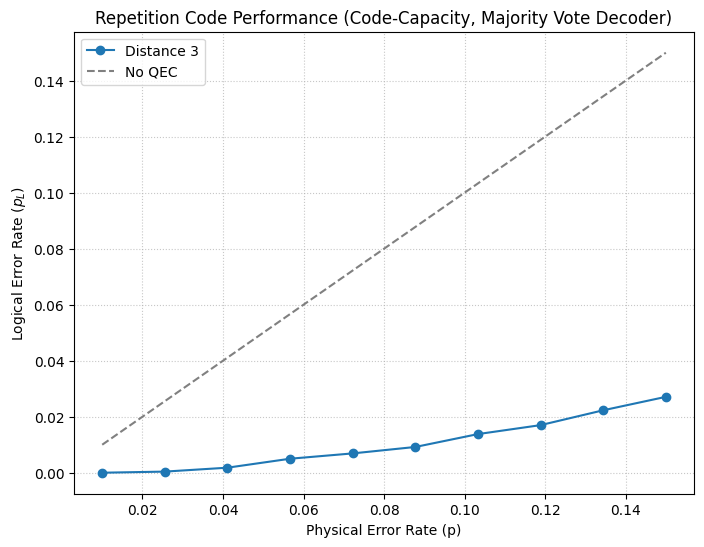

In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s2_stim_rep_code_majority.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's2_stim_rep_code_majority.py'

plt.savefig('../../figures/chapter_5/stim_rep_vote_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 3: Comparing MWPM and the Majority Vote decoders
The following code snippet shows the minimal source code to simulate a basic repetition code using the two decoders already implemented

```python
import matplotlib.pyplot as plt
from s1_stim_rep_code import sample_repetition_code_mwpm
from s2_stim_rep_code_majority import sample_repetition_code_mv

def plot_repetition_code_comparison(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates and plots a repetition code over a range of physical error rates,
    and compares the performance of the majority vote decoder with the MWPM decoder.
    """
    physical_error_rates_mv, logical_error_rates_mv = sample_repetition_code_mv(distance, shots)
    physical_error_rates_mwpm, logical_error_rates_mwpm = sample_repetition_code_mwpm(distance, shots)

    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates_mv, logical_error_rates_mv, marker='o', label=f'Majority Vote - Distance {distance}')
    plt.plot(physical_error_rates_mwpm, logical_error_rates_mwpm, marker='s', label=f'MWPM - Distance {distance}')

    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates_mv, physical_error_rates_mv, linestyle='--', color='gray', label='No QEC')
    
    plt.title('Repetition Code Performance (Code-Capacity, Majority Vote Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_comparison(distance=3, shots=10000)
```

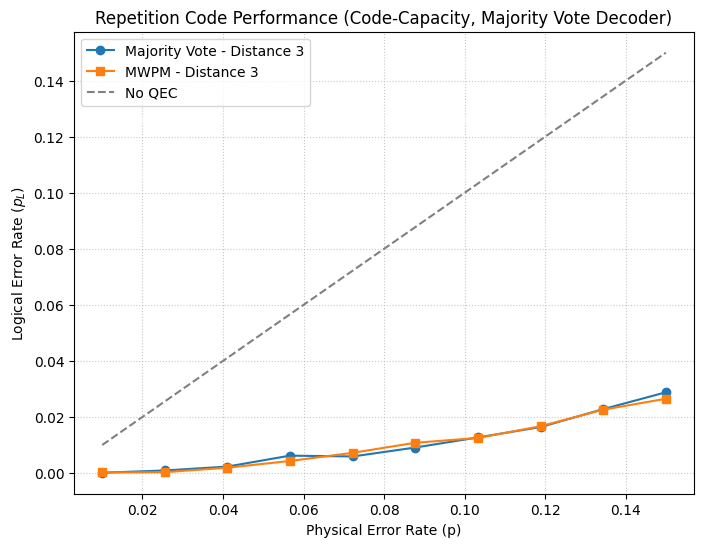

In [9]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s3_stim_rep_comparison.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's3_stim_rep_comparison.py'

plt.savefig('../../figures/chapter_5/stim_rep_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 4: Introducing circuit level and phenomenological noise
The following code snippet shows the necessary changes to introduce more complex noise models

```python
import stim
import numpy as np
from s2_majority_vote_decoder import decode_batch_majority_vote

def sample_repetition_code_mv(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p,
            after_clifford_depolarization=p,
            before_measure_flip_probability=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        # Decode the syndromes using our decoder
        predicted_observables = decode_batch_majority_vote(syndromes, circuit, distance)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)
    return physical_error_rates, logical_error_rates
```

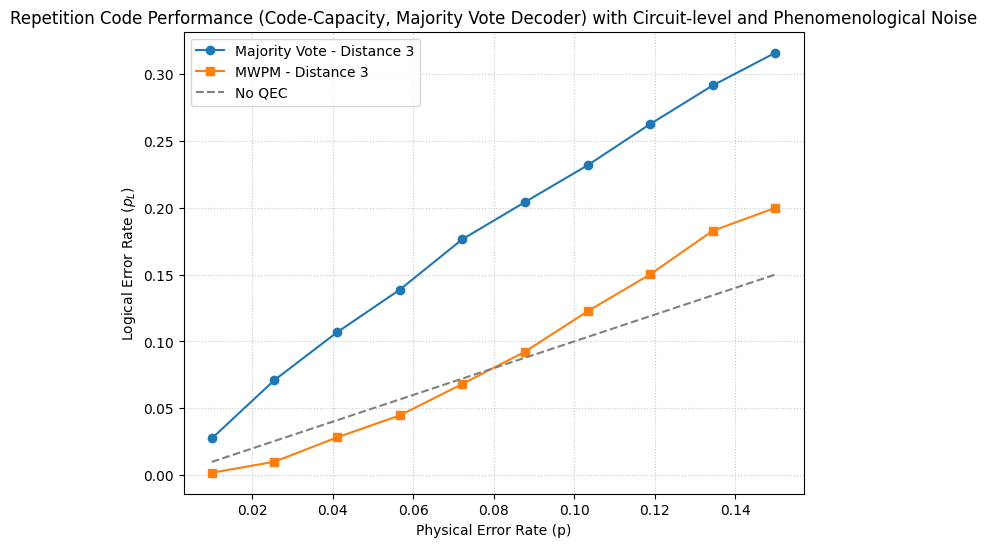

In [11]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s4_majority_vote_noise.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's4_stim_rep_circuit_noise.py'

plt.savefig('../../figures/chapter_5/stim_rep_circuit_noise_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 5: Visualizing the impact of code distance
The following code snippet shows the logical error rate for different code distances

```python
import matplotlib.pyplot as plt
from s4_mwpm_noise import sample_repetition_code_mwpm
from s4_majority_vote_noise import sample_repetition_code_mv

def plot_repetition_code_comparison(distances: list = [3, 5, 7], shots: int = 10000) -> None:
    """
    Simulates and plots a repetition code over a range of physical error rates,
    and compares the performance of the majority vote decoder with the MWPM decoder.
    """
    # Plotting the results
    plt.figure(figsize=(8, 6))
    for distance in distances:
        physical_error_rates_mv, logical_error_rates_mv = sample_repetition_code_mv(distance, shots)
        physical_error_rates_mwpm, logical_error_rates_mwpm = sample_repetition_code_mwpm(distance, shots)

        plt.plot(physical_error_rates_mv, logical_error_rates_mv, marker='o', label=f'Majority Vote - Distance {distance}')
        plt.plot(physical_error_rates_mwpm, logical_error_rates_mwpm, marker='s', label=f'MWPM - Distance {distance}')

    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates_mv, physical_error_rates_mv, linestyle='--', color='gray', label='No QEC')
    
    plt.title('Repetition Code Performance at different distances')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_comparison(distances=[3, 5, 7], shots=10000)
```

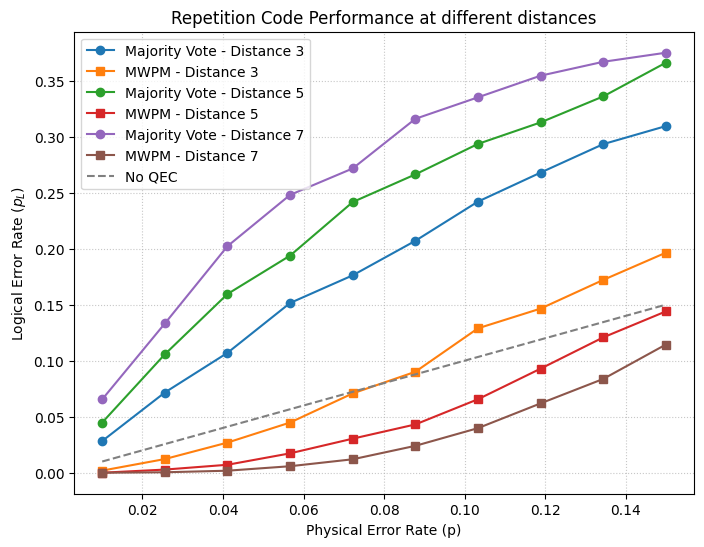

In [15]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s5_stim_rep_circuit_distance.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's5_stim_rep_circuit_distance.py'

plt.savefig('../../figures/chapter_5/stim_rep_circuit_distance_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 6: 9-qubit Shor Code simulation
The following code snippet shows the implementation and simulation of the 9-qubit Shor code under a code-capacity noise model using the MWPM decoder.

```python
import stim
import pymatching
import numpy as np

#BEGIN S6_SNIPPET_NOISY_GATE
def append_noisy_gate(circuit: stim.Circuit, gate: str, targets: list, noise: float) -> None:
    """Appends a gate and adds depolarizing noise if noise > 0."""
    circuit.append(gate, targets)
    if noise > 0:
        if gate in ["CX", "CY", "CZ", "SWAP"]:
            circuit.append("DEPOLARIZE2", targets, noise)
        else:
            circuit.append("DEPOLARIZE1", targets, noise)
#END S6_SNIPPET_NOISY_GATE

#BEGIN S6_SNIPPET_NOISY_MEASUREMENT
def append_noisy_measurement(circuit: stim.Circuit, targets: list, noise: float) -> None:
    """Appends a measurement with pre-measurement bit-flip noise."""
    if noise > 0:
        circuit.append("X_ERROR", targets, noise)
    circuit.append("M", targets)
#END S6_SNIPPET_NOISY_MEASUREMENT

def build_shor_circuit(
    rounds: int = 3, 
    state: str = "0",
    before_round_data_depolarization: float = 0.0,
    after_clifford_depolarization: float = 0.0,
    before_measure_flip_probability: float = 0.0
) -> stim.Circuit:
    """Builds the 9-qubit Shor code circuit with state initialization and adaptive observables."""
    if state in ["0", "1"]: basis = "Z"
    elif state in ["+", "-"]: basis = "X"
    elif state in ["+i", "-i"]: basis = "Y"
    else: raise ValueError("Invalid state")

    circuit = stim.Circuit()
    circuit.append("R", range(17))
    
    # State initialization
    if state == "1": append_noisy_gate(circuit, "X", [0], after_clifford_depolarization)
    elif state == "+": append_noisy_gate(circuit, "H", [0], after_clifford_depolarization)
    elif state == "-":
        append_noisy_gate(circuit, "X", [0], after_clifford_depolarization)
        append_noisy_gate(circuit, "H", [0], after_clifford_depolarization)
    elif state == "+i":
        append_noisy_gate(circuit, "H", [0], after_clifford_depolarization)
        append_noisy_gate(circuit, "S", [0], after_clifford_depolarization)
    elif state == "-i":
        append_noisy_gate(circuit, "X", [0], after_clifford_depolarization)
        append_noisy_gate(circuit, "H", [0], after_clifford_depolarization)
        append_noisy_gate(circuit, "S", [0], after_clifford_depolarization)

    # Shor Encoding
    append_noisy_gate(circuit, "CX", [0, 3, 0, 6], after_clifford_depolarization)
    append_noisy_gate(circuit, "H", [0, 3, 6], after_clifford_depolarization)
    encoding_cx = [0, 1, 0, 2, 3, 4, 3, 5, 6, 7, 6, 8]
    append_noisy_gate(circuit, "CX", encoding_cx, after_clifford_depolarization)
    circuit.append("TICK")

    #BEGIN S6_SNIPPET_ROUND_NOISE
    # Syndrome measurement rounds
    for r in range(rounds):
        if before_round_data_depolarization > 0:
            circuit.append("DEPOLARIZE1", range(9), before_round_data_depolarization)
    #END S6_SNIPPET_ROUND_NOISE
        # Bit-flip syndromes (Z-ancillas 9-14 measuring X stabilizers which are pairs of data qubits)
        z_targets = [0,9, 1,9, 1,10, 2,10, 3,11, 4,11, 4,12, 5,12, 6,13, 7,13, 7,14, 8,14]
        circuit.append("R", range(9, 15))
        append_noisy_gate(circuit, "CX", z_targets, after_clifford_depolarization)
        #BEGIN S6_SNIPPET_MEASURE_DETECTORS
        append_noisy_measurement(circuit, range(9, 15), before_measure_flip_probability)
        for i in range(6):
            if r == 0: circuit.append("DETECTOR", [stim.target_rec(-6 + i)])
            else: circuit.append("DETECTOR", [stim.target_rec(-6 + i), stim.target_rec(-6 + i - 8)])
        #END S6_SNIPPET_MEASURE_DETECTORS
        circuit.append("TICK")

        # Phase-flip syndromes (X-ancillas 15-16 measuring Z stabilizers which are qubits 1-6 and 3-9)
        circuit.append("R", [15, 16])
        append_noisy_gate(circuit, "H", [15, 16], after_clifford_depolarization)
        x_targets = []
        for d in range(6): x_targets.extend([15, d])
        for d in range(3, 9): x_targets.extend([16, d])
        append_noisy_gate(circuit, "CX", x_targets, after_clifford_depolarization)
        append_noisy_gate(circuit, "H", [15, 16], after_clifford_depolarization)
        append_noisy_measurement(circuit, [15, 16], before_measure_flip_probability)
        for i in range(2):
            if r == 0: circuit.append("DETECTOR", [stim.target_rec(-2 + i)])
            else: circuit.append("DETECTOR", [stim.target_rec(-2 + i), stim.target_rec(-2 + i - 8)])
        circuit.append("TICK")

    if basis == "Z":
        append_noisy_gate(circuit, "H", range(9), after_clifford_depolarization)
    elif basis == "Y":
        append_noisy_gate(circuit, "S_DAG", range(9), after_clifford_depolarization)
        append_noisy_gate(circuit, "H", range(9), after_clifford_depolarization)
    
    #BEGIN S6_SNIPPET_FINAL_MEASUREMENT
    append_noisy_measurement(circuit, range(9), before_measure_flip_probability)

    # Boundary detectors and observables
    if basis == "X":
        for i, targets in enumerate([(0,1), (1,2), (3,4), (4,5), (6,7), (7,8)]):
            circuit.append("DETECTOR", [stim.target_rec(-17 + i), stim.target_rec(-9 + targets[0]), stim.target_rec(-9 + targets[1])])
        # Logical X Distinguishes + and - (Measure Z0*Z3*Z6)
        circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(-9), stim.target_rec(-6), stim.target_rec(-3)], 0)
    elif basis == "Z":
        circuit.append("DETECTOR", [stim.target_rec(-11)] + [stim.target_rec(-i) for i in range(4, 10)])
        circuit.append("DETECTOR", [stim.target_rec(-10)] + [stim.target_rec(-i) for i in range(1, 7)])
        # Logical Z Distinguishes 0 and 1 (Measure transversal X parity)
        circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(-i) for i in range(1, 10)], 0)
    else:
        # For basis Y, we just measure transversal parity
        circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(-i) for i in range(1, 10)], 0)
    #END S6_SNIPPET_FINAL_MEASUREMENT

    return circuit

def sample_shor_code_mwpm(shots=10000, rounds=1, states=["0"], p_rates=None, noise_ratios=(1,0,0)):
    """General purpose sampling for Shor code MWPM decoding."""
    if p_rates is None: p_rates = np.linspace(0.01, 0.12, 8)
    l_rates = []
    r_data, r_measure, r_gate = noise_ratios
    
    for p in p_rates:
        errors = 0
        shots_per_state = shots // len(states)
        for state in states:
            circuit = build_shor_circuit(
                rounds=rounds, state=state,
                before_round_data_depolarization=p*r_data,
                after_clifford_depolarization=p*r_gate,
                before_measure_flip_probability=p*r_measure
            )
            sampler = circuit.compile_detector_sampler()
            syndromes, obs = sampler.sample(shots_per_state, separate_observables=True)
            matcher = pymatching.Matching.from_stim_circuit(circuit)
            predicted = matcher.decode_batch(syndromes)
            errors += np.sum(predicted != obs)
        l_rates.append(errors / (shots_per_state * len(states)))
    return p_rates, l_rates

def run_shor_simulations(shots: int = 2000):
    """Executes the three main comparative simulations for Chapter 5 and prints a text summary."""
    print("Executing Shor 9-qubit comprehensive simulations...")
    p_rates = np.linspace(0.01, 0.12, 8)

    # 1. Noise Model Comparison
    print("\n--- Simulation: Noise Models (1 Round, State |0>) ---")
    models = {
        "L1: $E_{data}$": (1, 0, 0),
        "L2: $E_{data} + E_{meas}$": (1, 1, 0),
        "L3: $E_{data} + E_{meas} + E_{gates}$": (1, 1, 1)
    }
    for label, ratios in models.items():
        _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=["0"], p_rates=p_rates, noise_ratios=ratios)
        mean_pl = np.mean(l_rates)
        print(f"{label:25} | Mean pL: {mean_pl:.4f} | Max pL: {max(l_rates):.4f}")

    # 2. Rounds Comparison
    print("\n--- Simulation: Rounds Comparison (Code Capacity, State |0>) ---")
    for r in [1, 3, 5]:
        _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=r, states=["0"], p_rates=p_rates, noise_ratios=(1, 0, 0))
        mean_pl = np.mean(l_rates)
        print(f"{r} Rounds                  | Mean pL: {mean_pl:.4f} | Max pL: {max(l_rates):.4f}")

    # 3. Cardinal States Comparison
    print("\n--- Simulation: Cardinal States (Code Capacity, 1 Round) ---")
    states_list = ["0", "1", "+", "-", "+i", "-i"]
    for state in states_list:
        _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=[state], p_rates=p_rates, noise_ratios=(1, 0, 0))
        mean_pl = np.mean(l_rates)
        print(f"State |{state:2}>                | Mean pL: {mean_pl:.4f}")
    
    _, mean_l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=states_list, p_rates=p_rates, noise_ratios=(1, 0, 0))
    print(f"{'Overall Mean':25} | Mean pL: {np.mean(mean_l_rates):.4f}")
    
    print("\nSimulations complete.")

if __name__ == "__main__":
    run_shor_simulations(shots=2000)

```

Running Simulation: Noise Models...


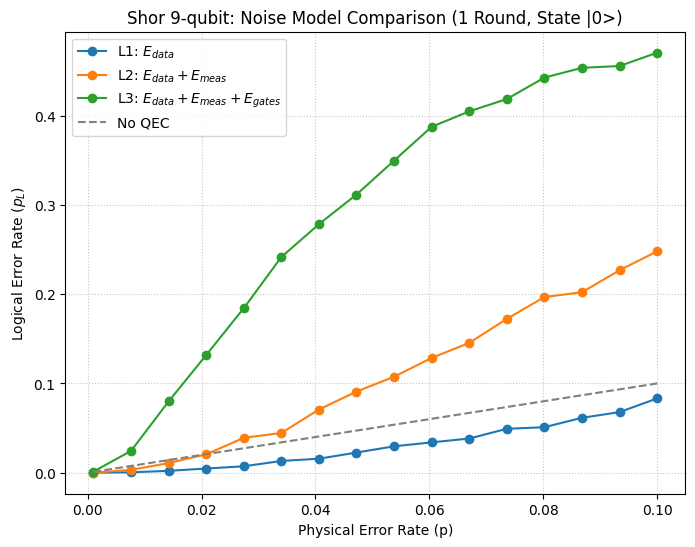

Running Simulation: Rounds...


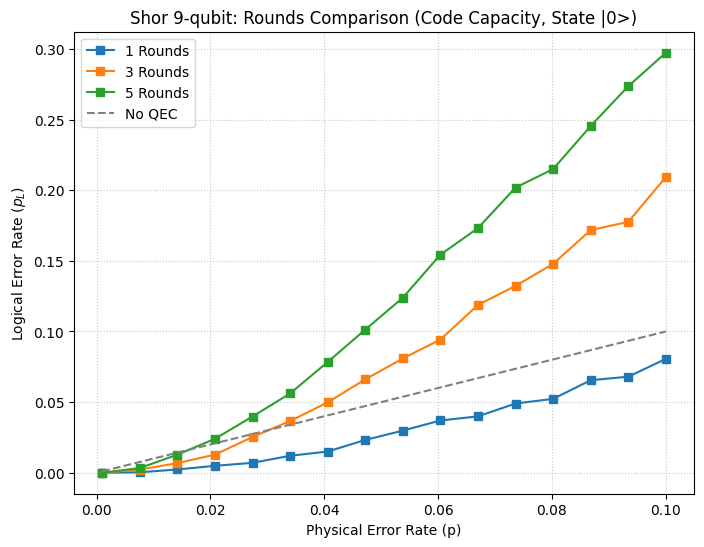

Running Simulation: Cardinal States...


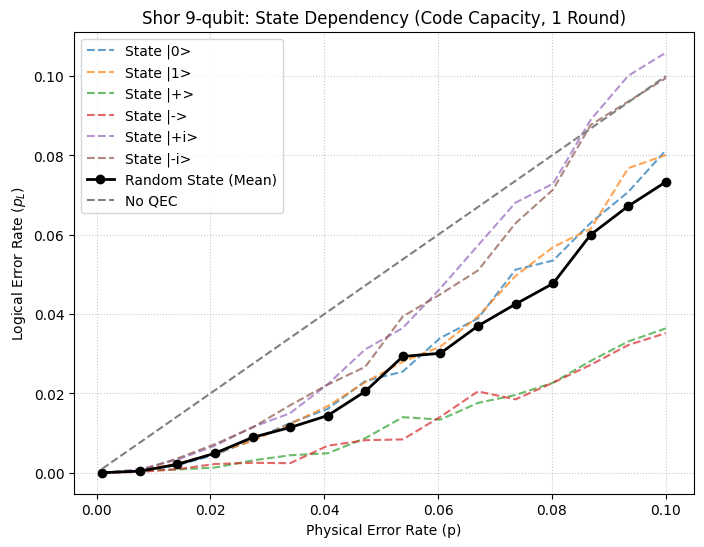

In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
from s6_shor_9_code import sample_shor_code_mwpm

with open('s6_shor_9_code.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

shots = 10000
p_rates = np.linspace(0.001, 0.10, 16)

# 1. Noise Model Comparison
print("Running Simulation: Noise Models...")
plt.figure(figsize=(8, 6))
models = {
    "L1: $E_{data}$": (1, 0, 0),
    "L2: $E_{data} + E_{meas}$": (1, 1, 0),
    "L3: $E_{data} + E_{meas} + E_{gates}$": (1, 1, 1)
}
for label, ratios in models.items():
    _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=["0"], p_rates=p_rates, noise_ratios=ratios)
    plt.plot(p_rates, l_rates, marker='o', label=label)
plt.plot(p_rates, p_rates, linestyle='--', color='gray', label='No QEC')
plt.title('Shor 9-qubit: Noise Model Comparison (1 Round, State |0>)')
plt.xlabel('Physical Error Rate (p)'); plt.ylabel('Logical Error Rate ($p_L$)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../../figures/chapter_5/shor_9_noise_models.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Rounds Comparison
print("Running Simulation: Rounds...")
plt.figure(figsize=(8, 6))
for r in [1, 3, 5]:
    _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=r, states=["0"], p_rates=p_rates, noise_ratios=(1, 0, 0))
    plt.plot(p_rates, l_rates, marker='s', label=f'{r} Rounds')
plt.plot(p_rates, p_rates, linestyle='--', color='gray', label='No QEC')
plt.title('Shor 9-qubit: Rounds Comparison (Code Capacity, State |0>)')
plt.xlabel('Physical Error Rate (p)'); plt.ylabel('Logical Error Rate ($p_L$)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../../figures/chapter_5/shor_9_rounds.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Cardinal States Comparison
print("Running Simulation: Cardinal States...")
plt.figure(figsize=(8, 6))
states_list = ["0", "1", "+", "-", "+i", "-i"]
for state in states_list:
    _, l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=[state], p_rates=p_rates, noise_ratios=(1, 0, 0))
    plt.plot(p_rates, l_rates, label=f'State |{state}>', alpha=0.7, linestyle='--')
_, mean_l_rates = sample_shor_code_mwpm(shots=shots, rounds=1, states=states_list, p_rates=p_rates, noise_ratios=(1, 0, 0))
plt.plot(p_rates, mean_l_rates, marker='o', color='black', linewidth=2, label='Random State (Mean)')
plt.plot(p_rates, p_rates, linestyle='--', color='gray', label='No QEC')
plt.title('Shor 9-qubit: State Dependency (Code Capacity, 1 Round)')
plt.xlabel('Physical Error Rate (p)'); plt.ylabel('Logical Error Rate ($p_L$)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../../figures/chapter_5/shor_9_states.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 7: The Threshold Theorem
The following code snippet demonstrates the Threshold Theorem using a repetition code under phenomenological noise (data + measurement errors) and the MWPM decoder for distances 3, 5, 7, and 9. We use `rounds = distance` to properly visualize the crossing at the threshold (~10.9%).

In [ ]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from s7_threshold_theorem import plot_threshold_theorem_comparison

with open('s7_threshold_theorem.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

# Execute and plot the simulation
print("Running Simulation: Threshold Theorem...")
plot_threshold_theorem_comparison(distances=[3, 5, 7, 9], shots=10000)
plt.savefig('../../figures/chapter_5/s7_threshold_theorem.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 8: advanced simulation using Sinter and Cirq
The following code snippet demonstrates how to use `cirq`, `stimcirq` and `sinter` together to programatically build a repetition code and collect statistics in parallel.

In [ ]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import os

with open('s8_beyond_stim.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

from s8_beyond_stim import sample_sinter_simulation, plot_sinter_simulation

print("Running Sinter simulation...")
# Run full simulation
stats, distances, physical_errors = sample_sinter_simulation()

# Plot results
plot_sinter_simulation(stats, distances, physical_errors)

fig_path = '../../figures/chapter_5/s8_beyond_stim_sinter.png'
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


### Simulation 9: Extracting Noise from Qiskit Fake Providers
The following code demonstrates how to extract physical error rates from a Qiskit backend, map them into a `cirq.NoiseModel`, automatically inject them into a clean `cirq` circuit.

```python
import matplotlib.pyplot as plt
import numpy as np
import sinter
import cirq
import stimcirq
import stim

try:
    from qiskit.providers.fake_provider import FakeManilaV2
except ImportError:
    from qiskit.providers.fake_provider import GenericBackendV2 as FakeManilaV2

#BEGIN S9_SNIPPET_EXTRACT
def get_average_error_rates(backend):
    """Extracts average error rates from a Qiskit backend."""
    target_1q = []
    target_2q = []
    target_meas = []
    
    for q in range(backend.num_qubits):
        meas_props = backend.target.get("measure", None)
        if meas_props is not None and (q,) in meas_props:
            target_meas.append(meas_props[(q,)].error)
            
        sx_props = backend.target.get("sx", None)
        if sx_props is not None and (q,) in sx_props:
            target_1q.append(sx_props[(q,)].error)

    cx_props = backend.target.get("cx", None)
    if cx_props is not None:
        for edge in cx_props:
            target_2q.append(cx_props[edge].error)
            
    p_1q = np.mean(target_1q) if target_1q else 0.001
    p_2q = np.mean(target_2q) if target_2q else 0.01
    p_meas = np.mean(target_meas) if target_meas else 0.02
    
    return p_1q, p_2q, p_meas

class IBMNoiseModel(cirq.NoiseModel):
    """Custom Cirq noise model applying extracted error rates."""
    def __init__(self, p_1q, p_2q, p_meas, scale=1.0):
        self.p_1q = min(p_1q * scale, 1.0)
        self.p_2q = min(p_2q * scale, 1.0)
        self.p_meas = min(p_meas * scale, 1.0)

    def noisy_operation(self, operation: cirq.Operation):
        if isinstance(operation, (stimcirq.DetAnnotation, stimcirq.CumulativeObservableAnnotation)):
            yield operation
            return

        if cirq.is_measurement(operation):
            yield cirq.bit_flip(p=self.p_meas).on_each(*operation.qubits)
            yield operation
        elif len(operation.qubits) == 1:
            yield operation
            yield cirq.depolarize(p=self.p_1q).on_each(*operation.qubits)
        elif len(operation.qubits) == 2:
            yield operation
            yield cirq.depolarize(p=self.p_2q).on_each(*operation.qubits)
        else:
            yield operation
#END S9_SNIPPET_EXTRACT

def build_clean_rep_code_cirq(distance: int) -> cirq.Circuit:
    """Builds a clean 1D Bit-Flip Repetition Code using Cirq without noise."""
    qubits = cirq.LineQubit.range(2 * distance - 1)
    circuit = cirq.Circuit()
    rounds = distance
    
    for r in range(rounds):
        circuit.append([cirq.CNOT(qubits[i-1], qubits[i]) for i in range(1, 2*distance-1, 2)], strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
        circuit.append([cirq.CNOT(qubits[i+1], qubits[i]) for i in range(1, 2*distance-1, 2)], strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
        
        circuit.append([cirq.measure(qubits[i], key=f'm_{r}_{i}') for i in range(1, 2*distance-1, 2)], strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
        
        det_ops = []
        for i in range(1, 2*distance-1, 2):
            key = f'm_{r}_{i}'
            if r == 0:
                det_ops.append(stimcirq.DetAnnotation(parity_keys=[key], coordinate_metadata=(i, r)))
            else:
                prev_key = f'm_{r-1}_{i}'
                det_ops.append(stimcirq.DetAnnotation(parity_keys=[key, prev_key], coordinate_metadata=(i, r)))
        circuit.append(det_ops, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
                
        circuit.append([cirq.reset(qubits[i]) for i in range(1, 2*distance-1, 2)], strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

    circuit.append([cirq.measure(qubits[i], key=f'd_{i}') for i in range(0, 2*distance-1, 2)], strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
        
    final_det_ops = []
    for i in range(1, 2*distance-1, 2):
        ancilla_key = f'm_{rounds-1}_{i}'
        data_left = f'd_{i-1}'
        data_right = f'd_{i+1}'
        final_det_ops.append(stimcirq.DetAnnotation(
            parity_keys=[ancilla_key, data_left, data_right],
            coordinate_metadata=(i, rounds)
        ))
    circuit.append(final_det_ops, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
        
    circuit.append(stimcirq.CumulativeObservableAnnotation(
        parity_keys=[f'd_0'],
        observable_index=0
    ), strategy=cirq.InsertStrategy.NEW_THEN_INLINE)
    
    return circuit

def sample_sinter_qiskit_noise(distances=None, scales=None, num_workers=8, max_shots=1000000, max_errors=500):
    """Runs a parallel simulation scaling the base Qiskit noise model."""
    try:
        backend = FakeManilaV2()
    except Exception:
        from qiskit.providers.fake_provider import GenericBackendV2
        backend = GenericBackendV2(num_qubits=5)
        
    base_1q, base_2q, base_meas = get_average_error_rates(backend)
    
    tasks = []
    if distances is None:
        distances = [3, 5, 7]
    if scales is None:
        scales = np.linspace(0.1, 15.0, 15)
    
    for d in distances:
        clean_circuit = build_clean_rep_code_cirq(distance=d)
        for scale in scales:
            #BEGIN S9_SNIPPET_WITH_NOISE
            noise_model = IBMNoiseModel(base_1q, base_2q, base_meas, scale=scale)
            noisy_circuit = clean_circuit.with_noise(noise_model)
            stim_circuit = stimcirq.cirq_circuit_to_stim_circuit(noisy_circuit)
            #END S9_SNIPPET_WITH_NOISE
            
            tasks.append(
                sinter.Task(
                    circuit=stim_circuit,
                    json_metadata={'d': d, 'scale': scale, 'p_2q': base_2q * scale}
                )
            )
            
    stats = sinter.collect(
        num_workers=num_workers,
        tasks=tasks,
        decoders=['pymatching'],
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=True
    )
    return stats, distances, scales

def plot_sinter_simulation(stats, distances):
    """Plots the results returned by the Sinter simulation."""
    plt.figure(figsize=(8, 6))
    for d in distances:
        d_stats = [s for s in stats if s.json_metadata['d'] == d]
        d_stats.sort(key=lambda s: s.json_metadata['p_2q'])
        
        p_rates = [s.json_metadata['p_2q'] for s in d_stats]
        l_rates = [s.errors / s.shots if s.shots > 0 else 0 for s in d_stats]
        plt.plot(p_rates, l_rates, marker='o', label=f'Distance {d}')
        
    ref_rates = [s.json_metadata['p_2q'] for s in [s for s in stats if s.json_metadata['d'] == distances[0]]]
    ref_rates.sort()
    plt.plot(ref_rates, ref_rates, linestyle='--', color='gray', label='No QEC')
    
    plt.xlabel('Physical 2Q Error Rate ($p_{2Q}$)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.title('Sinter Simulation: Qiskit Scaled Noise Model')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def main():
    print("Validating Sinter setup with scaled Qiskit noise...")
    stats, dists, scales = sample_sinter_qiskit_noise(
        distances=[3], 
        scales=[0.5, 1.0], 
        max_shots=10000, 
        num_workers=1
    )
    print("\nSimulation successful! Results:")
    for s in stats:
        print(s)

if __name__ == "__main__":
    main()

```

Running Sinter simulation with Qiskit extracted noise...


Starting 8 workers...
45 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                          
        1 pymatching   ?    1000000         500 d=3,scale=0.1,p_2q=0.0002796929069147813               
        1 pymatching   ?    1000000         500 d=3,scale=0.45000000000000007,p_2q=0.001258618081116516
        1 pymatching   ?    1000000         500 d=3,scale=0.8,p_2q=0.0022375432553182503               
        1 pymatching <1m     870703         462 d=3,scale=1.1500000000000001,p_2q=0.0032164684295199852
        1 pymatching   ?    1000000         500 d=3,scale=1.5000000000000002,p_2q=0.00419539360372172  
        1 pymatching   ?    1000000         500 d=3,scale=1.8500000000000003,p_2q=0.005174318777923455 
        1 pymatching   ?    1000000         500 d=3,scale=2.2,p_2q=0.006153243952125189                
        1 pymatching   ?    1000000         500 d=3,scale=2.5500000000000003,p_2q=0.007132169126326924 
        0 pymatching ?·∞   

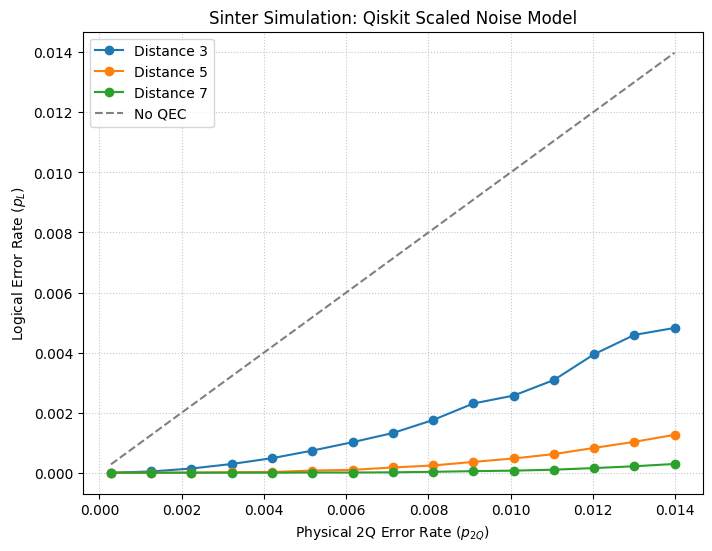

<Figure size 640x480 with 0 Axes>

In [14]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import os

with open('s9_qiskit_noise_model.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

from s9_qiskit_noise_model import sample_sinter_qiskit_noise, plot_sinter_simulation

print("Running Sinter simulation with Qiskit extracted noise...")
# Run full simulation
stats, distances, scales = sample_sinter_qiskit_noise()

# Plot results
plot_sinter_simulation(stats, distances)

fig_path = '../../figures/chapter_5/s9_qiskit_noise_model.png'
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
